In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
price = pd.read_csv('price.csv')
pe = pd.read_csv('pe.csv')
si = pd.read_csv('si.csv')

In [ ]:
price.head()

,Date,Last Price
0,2/18/25,409.64
1,2/14/25,408.43
2,2/13/25,410.54
3,2/12/25,409.04
4,2/11/25,411.44


In [ ]:
si.head()

,Date,Short Interest Ratio
0,02/14/2025,2.620451
1,01/31/2025,2.308294
2,01/15/2025,3.467132
3,12/31/2024,2.905123
4,12/13/2024,2.994566


In [ ]:
si['Date'] = pd.to_datetime(si['Date'])
si = si.sort_values(by='Date')
si = si.set_index('Date')  # Set 'Date' as the index

# Create a complete daily date range
full_date_range = pd.date_range(start=si.index.min(), end=si.index.max(), freq='D')

# Reindex to fill in missing dates
si = si.reindex(full_date_range)

# Forward-fill missing values with the previous value
si = si.ffill()

# Reset the index (optional)
si = si.reset_index()

In [ ]:
price['Date'] = pd.to_datetime(price['Date'], format='%m/%d/%y')
pe['Date'] = pd.to_datetime(pe['Date'], format='%m/%d/%y')

# Merge the data and sort it from ealierst to newest
merged_df = pd.merge(price, pe, on='Date', how='inner')
merged_df = merged_df.sort_values(by='Date')
merged_df2 = pd.merge(si, merged_df, left_on='index', right_on='Date', how='inner')
merged_df2 = merged_df2.reset_index(drop=True)

df = merged_df2.rename(columns={'Date': 'date', 'Last Price': 'price', 'Price Earnings Ratio (P/E)': 'pe', 'Short Interest Ratio': 'si'})
df

,index,si,date,price,pe
0,1991-02-15,1.477294,1991-02-15,1.4340,35.7266
1,1991-02-19,1.477294,1991-02-19,1.4236,35.4671
2,1991-02-20,1.477294,1991-02-20,1.4271,35.5536
3,1991-02-21,1.477294,1991-02-21,1.3889,34.6021
4,1991-02-22,1.477294,1991-02-22,1.4201,35.3806
...,...,...,...,...,...
8557,2025-02-10,2.308294,2025-02-10,412.2200,33.0729
8558,2025-02-11,2.308294,2025-02-11,411.4400,33.0103
8559,2025-02-12,2.308294,2025-02-12,409.0400,32.8177
8560,2025-02-13,2.308294,2025-02-13,410.5400,32.9381


### 5. Partition your data into a train and test set. You should have a minimum 7 years of data in your testing set.

In [ ]:
# Have a minimum 7 years of data in the testing set
train = df[df['date'] < '2018-01-01'].copy()
test = df[df['date'] >= '2018-01-01'].copy()

print('Range of train and test set:')
print(f"Train set: {train['date'].min()} to {train['date'].max()}")
print(f"Test set: {test['date'].min()} to {test['date'].max()}")

Range of train and test set:
Train set: 1991-01-15 00:00:00 to 2017-12-29 00:00:00
Test set: 2018-01-02 00:00:00 to 2025-02-14 00:00:00


### 6. Use the training set to produce a heatmap of your hyperparameters with the return of the strategy over the training set as the evaluation metric.

## 1
### SI + P/E
## Optimizing windows for si and p/e, using MA only no std.

In [ ]:
windows = list(range(1, 500, 5))

grid_results = []
for w1 in windows:
    for w2 in windows:
        train['Signal'] = 0

        ma_pe = train['pe'].rolling(window=w1).mean()
        ma_si = train['si'].rolling(window=w2).mean()

        train.loc[(train['pe'] < ma_pe)|(train['si'] > ma_si), 'Signal'] = 1  # Long
        train.loc[(train['pe'] > ma_pe)|(train['si'] < ma_si), 'Signal'] = -1  # Short

        # Compute strategy returns
        train['log_return']=np.log(train['price']/train['price'].shift(1))
        train['strategy_log_return']=train['Signal'].shift(1)*train['log_return']
        train['cum_return']=train['strategy_log_return'].cumsum()
        total_return=np.exp(train['cum_return'])-1

        # Store results for the heatmap
        grid_results.append({'Window (PE)': w1, 'Window (SI)': w2, 'Return': total_return.iloc[-1]})

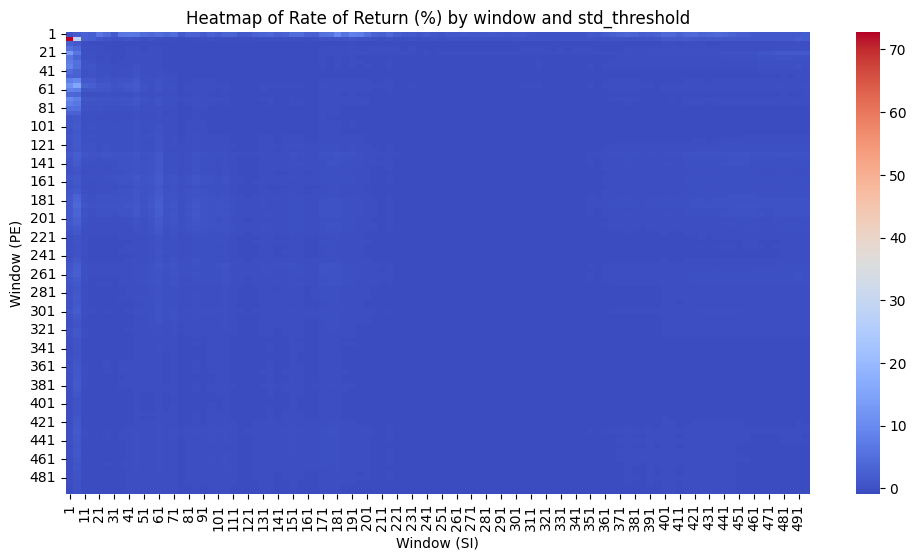

In [ ]:
results_df = pd.DataFrame(grid_results)
heatmap_data = results_df.pivot(index='Window (PE)', columns='Window (SI)', values='Return')

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=False, fmt=".2f")
plt.xlabel('Window (SI)')
plt.ylabel('Window (PE)')
plt.title('Heatmap of Rate of Return (%) by window and std_threshold')
plt.show()

## 2
### Short interest +P/E
### Optimizing windows and threshold for si and p/e, using MA and t*std.

In [ ]:
windows = list(range(1, 100, 1))
std_thresholds = np.arange(0, 1, 0.01)

grid_results = []
for w1 in windows:
    for t in std_thresholds:
        train['Signal'] = 0

        ma_pe = train['pe'].rolling(window=w1).mean()
        std_pe = train['pe'].rolling(window=w1).std()
        ma_si = train['si'].rolling(window=w1).mean()
        std_si = train['si'].rolling(window=w1).std()

        train.loc[(train['pe'] < ma_pe-std_pe*t)|(train['si'] > ma_si+std_si*t), 'Signal'] = 1  # Long
        train.loc[(train['pe'] > ma_pe+std_pe*t)|(train['si'] < ma_si-std_si*t), 'Signal'] = -1  # Short

        # Compute strategy returns
        train['log_return']=np.log(train['price']/train['price'].shift(1))
        train['strategy_log_return']=train['Signal'].shift(1)*train['log_return']
        train['cum_return']=train['strategy_log_return'].cumsum()
        total_return=np.exp(train['cum_return'])-1

        # Store results for the heatmap
        grid_results.append({'Window': w1, 'Threshold': t, 'Return': total_return.iloc[-1]})

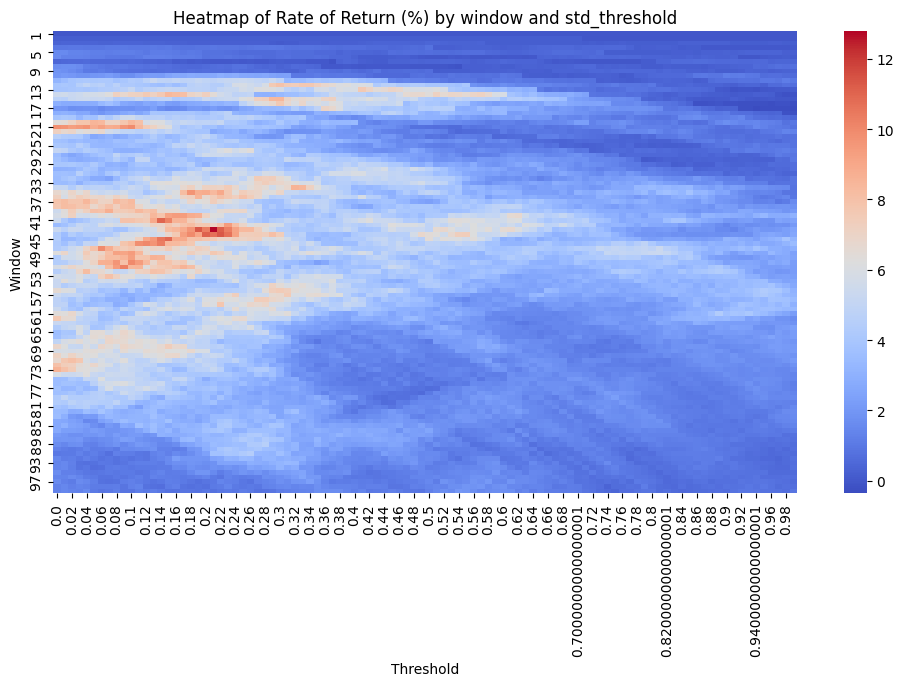

In [ ]:
results_df = pd.DataFrame(grid_results)
heatmap_data = results_df.pivot(index='Window', columns='Threshold', values='Return')

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=False, fmt=".2f")
plt.xlabel('Threshold')
plt.ylabel('Window')
plt.title('Heatmap of Rate of Return (%) by window and std_threshold')
plt.show()

In [ ]:
windows = list(range(1, 500, 15))
std_thresholds = np.arange(0, 1, 0.01)

grid_results = []
for w1 in windows:
    for t in std_thresholds:
        train['Signal'] = 0

        ma_pe = train['pe'].rolling(window=w1).mean()
        std_pe = train['pe'].rolling(window=w1).std()
        ma_si = train['si'].rolling(window=w1).mean()
        std_si = train['si'].rolling(window=w1).std()

        train.loc[(train['pe'] < ma_pe)&(train['si'] > ma_si+std_si*t), 'Signal'] = 1  # Long
        train.loc[(train['pe'] > ma_pe)&(train['si'] < ma_si-std_si*t), 'Signal'] = -1  # Short

        # Compute strategy returns
        train['log_return']=np.log(train['price']/train['price'].shift(1))
        train['strategy_log_return']=train['Signal'].shift(1)*train['log_return']
        train['cum_return']=train['strategy_log_return'].cumsum()
        total_return=np.exp(train['cum_return'])-1

        # Store results for the heatmap
        grid_results.append({'Window': w1, 'Threshold': t, 'Return': total_return.iloc[-1]})

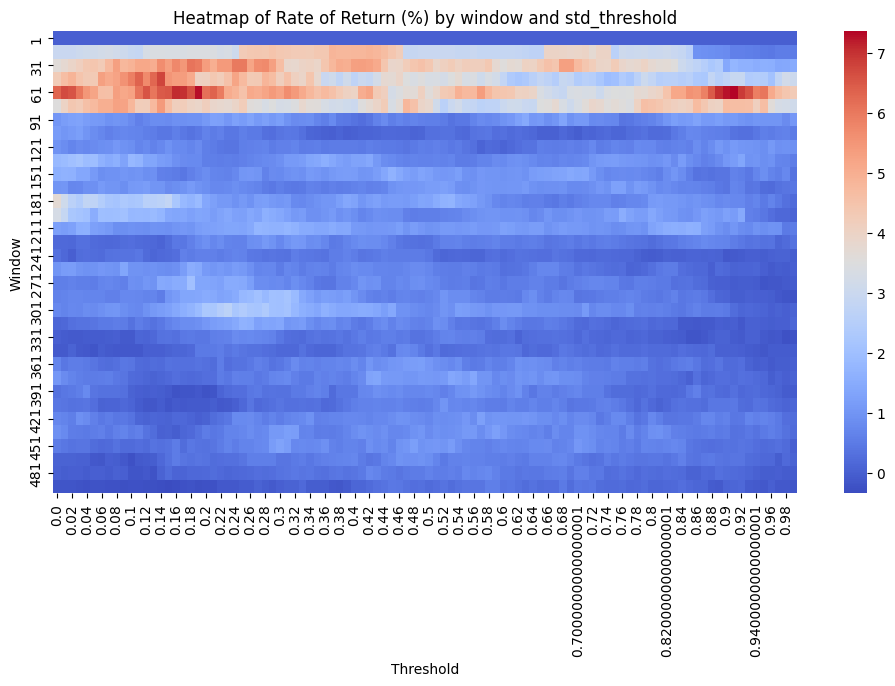

In [ ]:
results_df = pd.DataFrame(grid_results)
heatmap_data = results_df.pivot(index='Window', columns='Threshold', values='Return')

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=False, fmt=".2f")
plt.xlabel('Threshold')
plt.ylabel('Window')
plt.title('Heatmap of Rate of Return (%) by window and std_threshold')
plt.show()

In [ ]:
windows = list(range(1, 100, 1))
std_thresholds = np.arange(0, 1, 0.01)

grid_results = []
for w1 in windows:
    for t in std_thresholds:
        train['Signal'] = 0

        ma_pe = train['pe'].rolling(window=w1).mean()
        std_pe = train['pe'].rolling(window=w1).std()
        ma_si = train['si'].rolling(window=w1).mean()
        std_si = train['si'].rolling(window=w1).std()

        train.loc[(train['pe'] < ma_pe-std_pe*t)&(train['si'] > ma_si), 'Signal'] = 1  # Long
        train.loc[(train['pe'] > ma_pe+std_pe*t)&(train['si'] < ma_si), 'Signal'] = -1  # Short

        # Compute strategy returns
        train['log_return']=np.log(train['price']/train['price'].shift(1))
        train['strategy_log_return']=train['Signal'].shift(1)*train['log_return']
        train['cum_return']=train['strategy_log_return'].cumsum()
        total_return=np.exp(train['cum_return'])-1

        # Store results for the heatmap
        grid_results.append({'Window': w1, 'Threshold': t, 'Return': total_return.iloc[-1]})

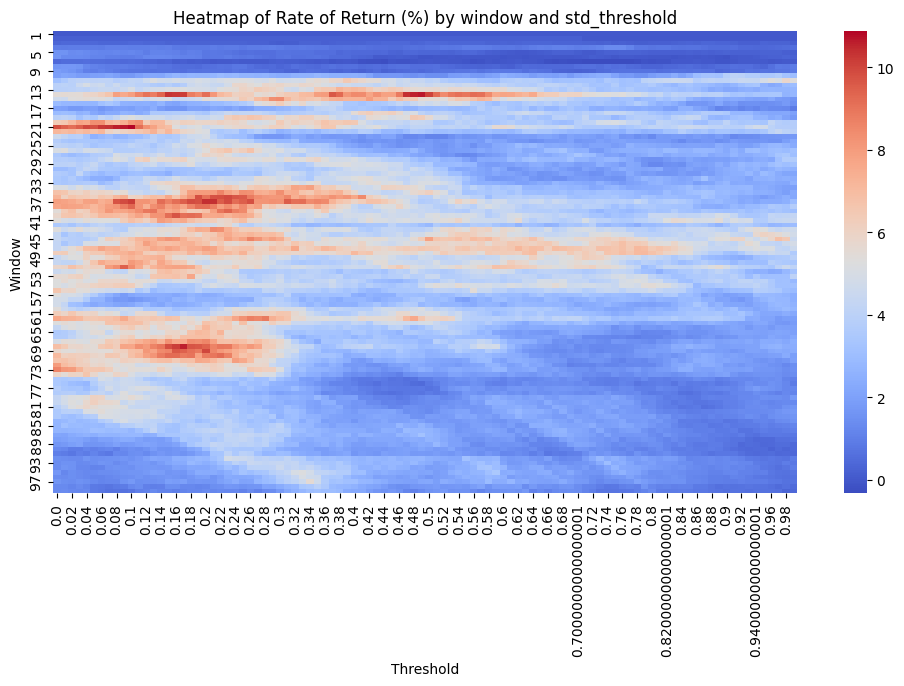

In [ ]:
results_df = pd.DataFrame(grid_results)
heatmap_data = results_df.pivot(index='Window', columns='Threshold', values='Return')

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=False, fmt=".2f")
plt.xlabel('Threshold')
plt.ylabel('Window')
plt.title('Heatmap of Rate of Return (%) by window and std_threshold')
plt.show()

In [ ]:
windows = list(range(1, 100, 1))
std_thresholds = np.arange(0, 1, 0.01)

grid_results = []
for w1 in windows:
    for t in std_thresholds:
        train['Signal'] = 0

        ma_pe = train['pe'].rolling(window=w1).mean()
        std_pe = train['pe'].rolling(window=w1).std()
        ma_si = train['si'].rolling(window=w1).mean()
        std_si = train['si'].rolling(window=w1).std()

        train.loc[(train['pe'] < ma_pe-std_pe*t)|(train['si'] > ma_si+std_si*t), 'Signal'] = 1  # Long
        train.loc[(train['pe'] > ma_pe+std_pe*t)|(train['si'] < ma_si-std_si*t), 'Signal'] = -1  # Short

        # Compute strategy returns
        train['log_return']=np.log(train['price']/train['price'].shift(1))
        train['strategy_log_return']=train['Signal'].shift(1)*train['log_return']
        train['cum_return']=train['strategy_log_return'].cumsum()
        total_return=np.exp(train['cum_return'])-1

        # Store results for the heatmap
        grid_results.append({'Window': w1, 'Threshold': t, 'Return': total_return.iloc[-1]})

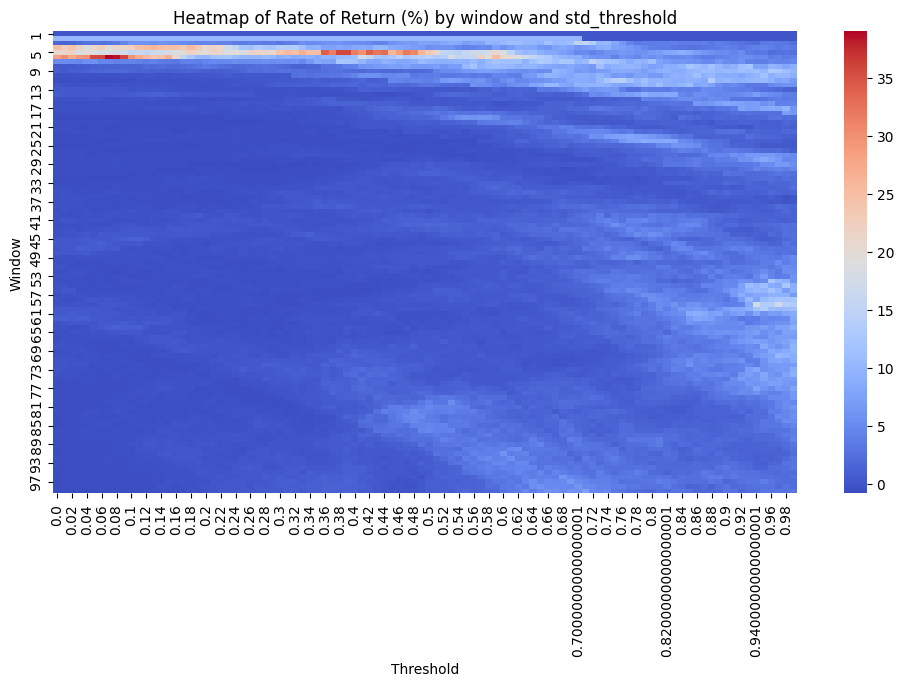

In [ ]:
results_df = pd.DataFrame(grid_results)
heatmap_data = results_df.pivot(index='Window', columns='Threshold', values='Return')

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=False, fmt=".2f")
plt.xlabel('Threshold')
plt.ylabel('Window')
plt.title('Heatmap of Rate of Return (%) by window and std_threshold')
plt.show()

In [ ]:
k_values = np.linspace(0.01, 1, 100)
z_values = np.linspace(0, 4, 100)

grid_results = []

for k in k_values:
    for z in z_values:
        train['ewm_mean'] = train['pe'].ewm(alpha=k).mean()
        train['filter_error'] = train['pe'] - train['ewm_mean']
        train['filter_error_std'] = train['filter_error'].ewm(alpha=k).std()

        train['ewm_mean1'] = train['si'].ewm(alpha=k).mean()
        train['filter_error1'] = train['si'] - train['ewm_mean1']
        train['filter_error_std1'] = train['filter_error1'].ewm(alpha=k).std()

        # Generate Trading Signals
        short_condition = (train['pe'] < train['ewm_mean'] - train['filter_error_std']*z)|(train['si'].diff(15)>0)
        long_condition = (train['pe'] > train['ewm_mean'] + train['filter_error_std']*z)|(train['si'].diff(15)<0)

        train['Signal'] = np.where(short_condition, -1, np.where(long_condition, 1, np.nan))
        train['Signal'] = train['Signal'].ffill()

        # Compute strategy returns
        train['log_return'] = np.log(train['price'] / train['price'].shift(1))
        train['strategy_log_return'] = train['Signal'].shift() * train['log_return']
        train['cum_return'] = train['strategy_log_return'].cumsum()
        total_return = np.exp(train['cum_return']) - 1  # Convert log returns to % returns

        # Store results for the heatmap
        grid_results.append({'k': k, 'z': z, 'Return': total_return.iloc[-1]})

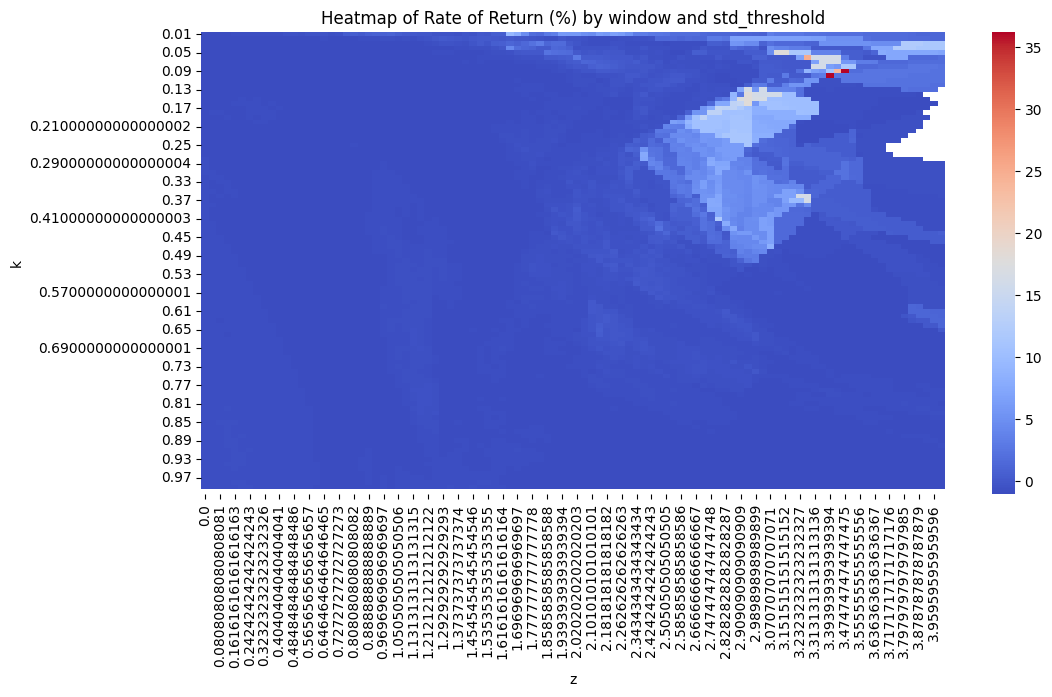

In [ ]:
results_df = pd.DataFrame(grid_results)
heatmap_data = results_df.pivot(index='k', columns='z', values='Return')

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=False, fmt=".2f")
plt.xlabel('z')
plt.ylabel('k')
plt.title('Heatmap of Rate of Return (%) by window and std_threshold')
plt.show()

In [ ]:
k_values = np.linspace(0.01, 1, 100)
z_values = np.linspace(0, 4, 100)

grid_results = []

for k in k_values:
    for z in z_values:
        train['ewm_mean'] = train['pe'].ewm(alpha=k).mean()
        train['filter_error'] = train['pe'] - train['ewm_mean']
        train['filter_error_std'] = train['filter_error'].ewm(alpha=k).std()

        train['ewm_mean1'] = train['pe'].ewm(alpha=k).mean()
        train['filter_error1'] = train['pe'] - train['ewm_mean1']
        train['filter_error_std1'] = train['filter_error1'].ewm(alpha=k).std()

        # Generate Trading Signals
        short_condition = (train['pe'] < train['ewm_mean'] - train['filter_error_std']*z)&(train['si'] > train['si'].rolling(window=180).mean())
        long_condition = (train['pe'] > train['ewm_mean'] + train['filter_error_std']*z)&(train['si'] < train['si'].rolling(window=180).mean())

        train['Signal'] = np.where(short_condition, -1, np.where(long_condition, 1, np.nan))
        train['Signal'] = train['Signal'].ffill()

        # Compute strategy returns
        train['log_return'] = np.log(train['price'] / train['price'].shift(1))
        train['strategy_log_return'] = train['Signal'].shift() * train['log_return']
        train['cum_return'] = train['strategy_log_return'].cumsum()
        total_return = np.exp(train['cum_return']) - 1  # Convert log returns to % returns

        # Store results for the heatmap
        grid_results.append({'k': k, 'z': z, 'Return': total_return.iloc[-1]})

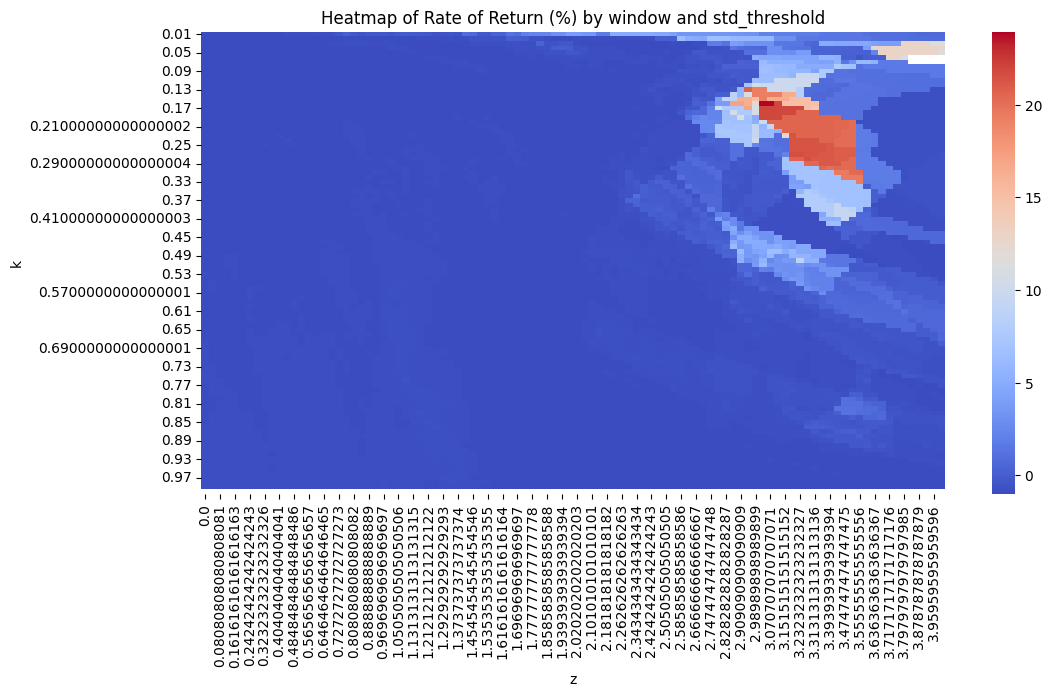

In [ ]:
results_df = pd.DataFrame(grid_results)
heatmap_data = results_df.pivot(index='k', columns='z', values='Return')

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=False, fmt=".2f")
plt.xlabel('z')
plt.ylabel('k')
plt.title('Heatmap of Rate of Return (%) by window and std_threshold')
plt.show()

In [ ]:
windows = list(range(1, 500, 1))
std_thresholds = np.arange(0, 1, 0.05)

grid_results = []
for window in windows:
    for threshold in windows:
        train['Signal'] = 0

        ma = train['pe'].rolling(window=window).mean()
        #std = train['pe'].rolling(window=window).std()

        ma_si = train['si'].rolling(window=threshold).mean()

        train.loc[(train['pe'] < ma)&(train['si'] > ma_si), 'Signal'] = 1  # Long
        train.loc[(train['pe'] > ma)&(train['si'] < ma_si), 'Signal'] = -1  # Short

        # Compute strategy returns
        train['log_return']=np.log(train['price']/train['price'].shift(1))
        train['strategy_log_return']=train['Signal'].shift(1)*train['log_return']
        train['cum_return']=train['strategy_log_return'].cumsum()
        total_return=np.exp(train['cum_return'])-1

        # Store results for the heatmap
        grid_results.append({'Window': window, 'Threshold': threshold, 'Return': total_return.iloc[-1]})

results_df = pd.DataFrame(grid_results)
heatmap_data = results_df.pivot(index='Window', columns='Threshold', values='Return')

In [ ]:
k_values = np.linspace(0.01, 1, 100)
z_values = np.linspace(0, 3.5, 100)

grid_results = []

for k in k_values:
    for w in windows:
        train['ewm_mean'] = train['pe'].ewm(alpha=k).mean()
        train['filter_error'] = train['pe'] - train['ewm_mean']
        train['filter_error_std'] = train['filter_error'].ewm(alpha=k).std()

        ma_si = train['si'].rolling(window=w).mean()

        # Generate Trading Signals
        short_condition = (train['pe'] < train['ewm_mean'])|(train['si'] > ma_si)
        long_condition = (train['pe'] > train['ewm_mean'])|(train['si'] < ma_si)

        train['Signal'] = np.where(short_condition, -1, np.where(long_condition, 1, np.nan))
        train['Signal'] = train['Signal'].ffill()

        # Compute strategy returns
        train['log_return'] = np.log(train['price'] / train['price'].shift(1))
        train['strategy_log_return'] = train['Signal'].shift() * train['log_return']
        train['cum_return'] = train['strategy_log_return'].cumsum()
        total_return = np.exp(train['cum_return']) - 1  # Convert log returns to % returns

        # Store results for the heatmap
        grid_results.append({'k': k, 'widnow': w, 'Return': total_return.iloc[-1]})

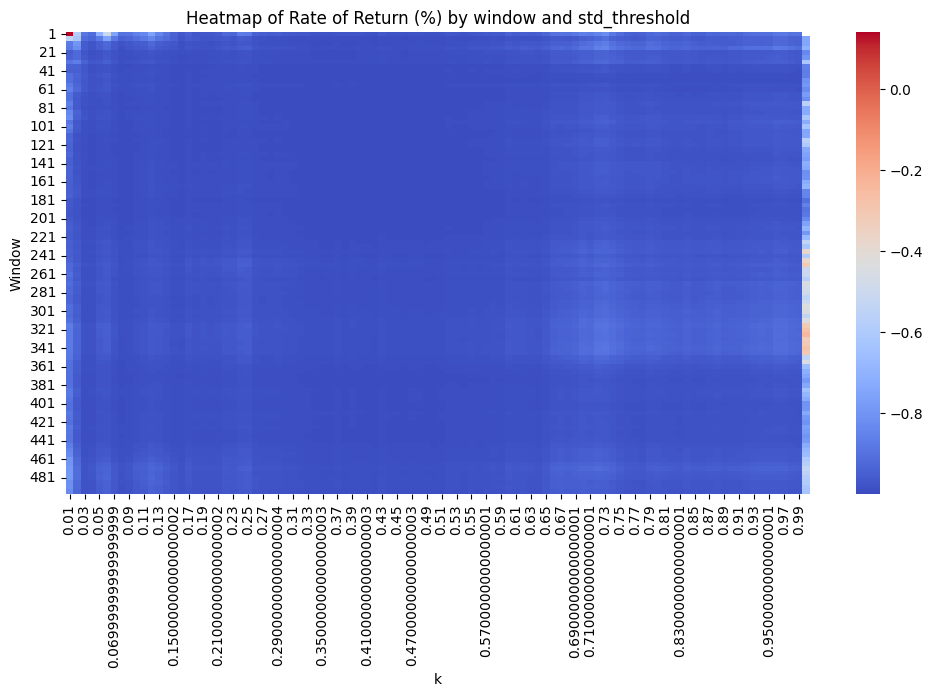

In [ ]:
results_df = pd.DataFrame(grid_results)
heatmap_data = results_df.pivot(index='widnow', columns='k', values='Return')

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=False, fmt=".2f")
plt.xlabel('k')
plt.ylabel('Window')
plt.title('Heatmap of Rate of Return (%) by window and std_threshold')
plt.show()

In [ ]:
k_values = np.linspace(0.01, 1, 100)
z_values = np.linspace(0, 3.5, 100)

grid_results = []

for k in k_values:
    for w in windows:
        train['ewm_mean'] = train['pe'].ewm(alpha=k).mean()
        train['filter_error'] = train['pe'] - train['ewm_mean']
        train['filter_error_std'] = train['filter_error'].ewm(alpha=k).std()

        ma_si = train['si'].rolling(window=threshold).mean()

        # Generate Trading Signals
        short_condition = (train['pe'] < train['ewm_mean'] - train['filter_error_std']*1.944)
        long_condition = (train['pe'] > train['ewm_mean'] + train['filter_error_std']*1.944)

        train['Signal'] = np.where(short_condition, -1, np.where(long_condition, 1, np.nan))
        train['Signal'] = train['Signal'].ffill()

        # Compute strategy returns
        train['log_return'] = np.log(train['price'] / train['price'].shift(1))
        train['strategy_log_return'] = train['Signal'].shift() * train['log_return']
        train['cum_return'] = train['strategy_log_return'].cumsum()
        total_return = np.exp(train['cum_return']) - 1  # Convert log returns to % returns

        # Store results for the heatmap
        grid_results.append({'k': k, 'widnow': w, 'Return': total_return.iloc[-1]})